# It's Official 📣
### The NBER tells you a recession started — months after it did. Is that the moment to buy?

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

**Real on the lead · None on the buy signal.** The stock market really does turn before the
official referee says so — but the day the referee speaks is not a special day to buy.

> 📓 **This is the plain-language layer.** The rotation tests, the power curve and the rule
> backtests are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is drawn from the real bundled tapes by the
> code beside it; the one synthetic chart says so in its title.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
GREEN, RED, BLUE, GREY, AMBER = "#2ea44f", "#c0392b", "#1f6feb", "#8b949e", "#dab617"

from nberclock import data, strategy as st
m = data.load_monthly()              # Fama-French monthly, TOTAL return, 1926-07 -> 2018-11
d = data.load_daily()                # S&P 500 daily PRICE index, 1990-01 -> 2022-11
tr = data.total_return_index(m)
xs = st.excess_index(m)
cyc, anns = data.cycles(), data.announcements()
print(f"monthly TR {m.index[0].date()} -> {m.index[-1].date()}  fp {data.fingerprint(m)}")
print(f"daily price {d.index[0].date()} -> {d.index[-1].date()}  fp {data.fingerprint(d)}")

def shade_recessions(ax, lo=None, hi=None):
    for _, c in cyc.iterrows():
        if (lo is None or c.trough >= lo) and (hi is None or c.peak <= hi):
            ax.axvspan(c.peak, c.trough, color=GREY, alpha=0.18, lw=0)

monthly TR 1926-07-31 -> 2018-11-30  fp 394be76d78ac
daily price 1990-01-02 -> 2022-11-30  fp e223c581ae22


## Beat 0 · The answer first (real tape)

| Question | Answer |
|---|---|
| Does the market turn before the NBER's dates? | Yes — the market bottomed first in 14 of 15 cycles since 1926. |
| Has the market "done its falling" by the peak announcement? | Sometimes. Median drawdown already in: −6.7%; in 2 of 6 there was no fall at all. |
| Has the recovery "long gone" by the trough announcement? | Yes. Median +63% off the low. |
| Is the announcement a buy signal? | No. +3.1% over the next year (above bills) vs +8.5% after random dates. |
| Could you trade it? | Every rule built on it lost to just holding. |

## Beat 1 · The claim

The folk version goes like this: *the National Bureau of Economic Research is so slow that by
the time it officially declares a recession, the stock market has already done its falling — so
the announcement is a buy signal. And by the time it declares the recovery, the cheap prices are
long gone.*

It sounds plausible because the first half is famous. The committee announced that the Great
Recession had begun on **1 December 2008** — a full year after it started. It announced the end
fifteen months after the end.

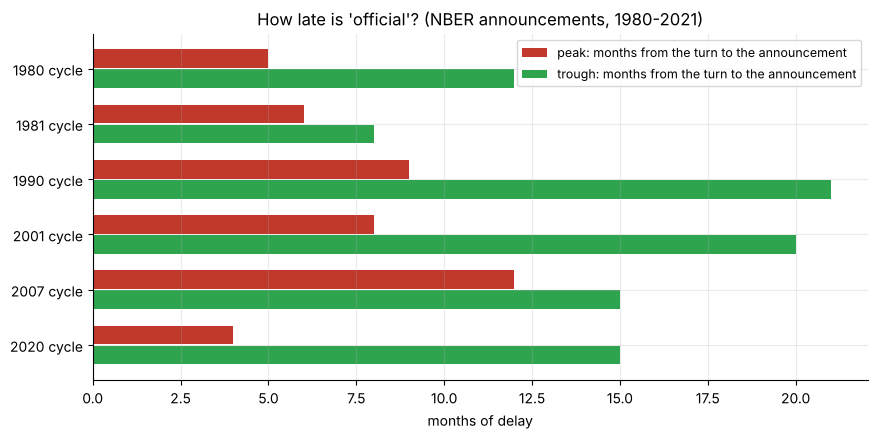

,kind,reference,date,lag_months
0,peak,1980-01,1980-06-03,5
1,trough,1980-07,1981-07-08,12
2,peak,1981-07,1982-01-06,6
3,trough,1982-11,1983-07-08,8
4,peak,1990-07,1991-04-25,9
5,trough,1991-03,1992-12-22,21
6,peak,2001-03,2001-11-26,8
7,trough,2001-11,2003-07-17,20
8,peak,2007-12,2008-12-01,12
9,trough,2009-06,2010-09-20,15


In [2]:
show = anns.assign(reference=anns.reference.dt.strftime("%Y-%m"),
                   date=anns.date.dt.strftime("%Y-%m-%d"))[["kind", "reference", "date",
                                                             "lag_months"]]
fig, ax = plt.subplots(figsize=(10, 4.5))
for kind, col, off in (("peak", RED, -0.18), ("trough", GREEN, 0.18)):
    a = anns[anns.kind == kind]
    ax.barh(np.arange(len(a)) + off, a.lag_months, height=0.34, color=col,
            label=f"{kind}: months from the turn to the announcement")
ax.set_yticks(range(6))
ax.set_yticklabels([f"{p.year} cycle" for p in anns[anns.kind == 'peak'].reference])
ax.invert_yaxis(); ax.set_xlabel("months of delay"); ax.legend(fontsize=9)
ax.set_title("How late is 'official'? (NBER announcements, 1980-2021)")
plt.show()
show

Peaks get announced a median **7 months** late; troughs a median **15**.
That delay is not sloppiness — the committee waits until the data are unambiguous — but it is
the raw material of the claim.

## Beat 2 · So what?

If the announcement really were a buy signal, it would be the rare market-timing rule that
needs no model, no data feed and no judgement: wait for a press release, buy. And it would say
something about markets — that investors keep selling into news everyone already knows.

## Beat 3 · How we'd know

Two separate questions, two separate tests, fixed before we looked:

1. **The lead.** Find the market's own peak and trough around each of the 16 NBER cycles since
   1926 and count how often the market turned first.
2. **The buy signal.** Compare the return over the year after each official announcement with
   the return after *random* dates. If the official dates aren't better than random ones, the
   announcement is not a signal — whatever the lead.

**"Mirage" would mean:** the market leads, the delay is real, and still nothing special happens
after the announcement.

## Beat 4 · The teardown

### 4.1 A century of cycles: the market moves first

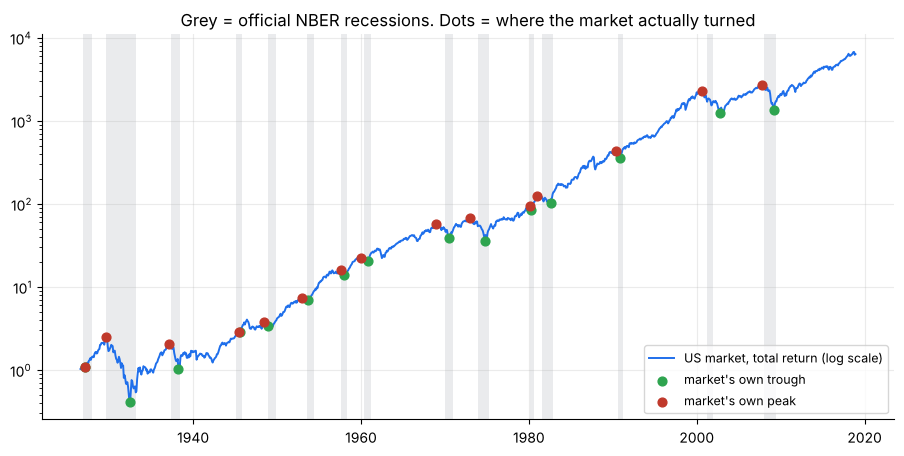

In [3]:
ll = st.lead_lag_all(tr, d, cyc)
fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogy(tr.index, tr, color=BLUE, lw=1.4, label="US market, total return (log scale)")
shade_recessions(ax, hi=tr.index[-1])
okk = ll[ll.tape == "FF total return"]
ax.scatter(okk.mkt_trough, tr.reindex(okk.mkt_trough), color=GREEN, s=40, zorder=3,
           label="market's own trough")
ax.scatter(okk.mkt_peak, tr.reindex(okk.mkt_peak), color=RED, s=40, zorder=3,
           label="market's own peak")
ax.set_title("Grey = official NBER recessions. Dots = where the market actually turned")
ax.legend(fontsize=9); plt.show()

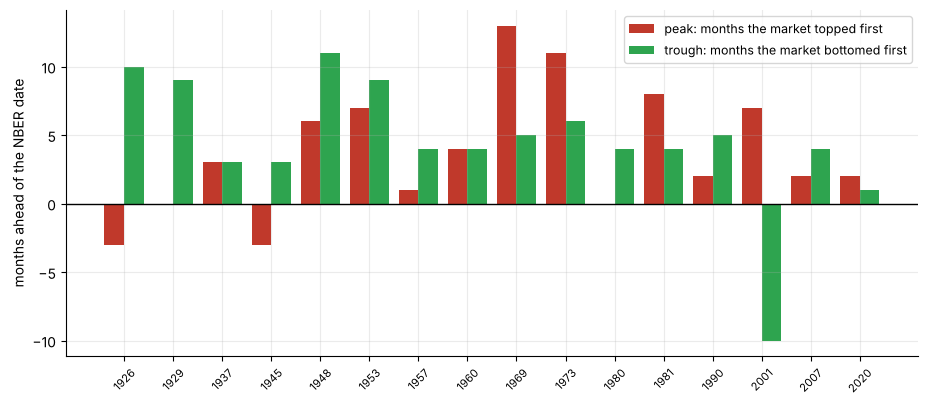

market bottomed first in 14 of 15 uncensored cycles; median lead 4 months


In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
lab = [p.strftime("%Y") for p in ll.peak]
x = np.arange(len(ll))
ax.bar(x - 0.2, ll.lead_peak, width=0.4, color=RED, label="peak: months the market topped first")
ax.bar(x + 0.2, ll.lead_trough, width=0.4, color=GREEN,
       label="trough: months the market bottomed first")
ax.axhline(0, color="k", lw=1)
ax.set_xticks(x); ax.set_xticklabels(lab, rotation=45, fontsize=8)
ax.set_ylabel("months ahead of the NBER date"); ax.legend(fontsize=9)
plt.show()
s = st.lead_summary(ll)
print(f"market bottomed first in {s['trough_pos']} of {s['n']} uncensored cycles; "
      f"median lead {s['trough_median']:.0f} months")

Almost every bar is above zero. The one big exception is 2001: the official recession ended in
November 2001, but the dot-com bear market kept going until late 2002.

> 🔬 **For the quants.** The rule that finds "the market's trough" is not neutral — on a rising
> market it tends to find a low early. Run on the same tape with the NBER calendar shifted to
> arbitrary months, it puts the market first 71% of the time. The real calendar
> (93%) still beats that (p = 0.032), but the *size* of the lead does not.

### 4.2 On announcement day: what was already done?

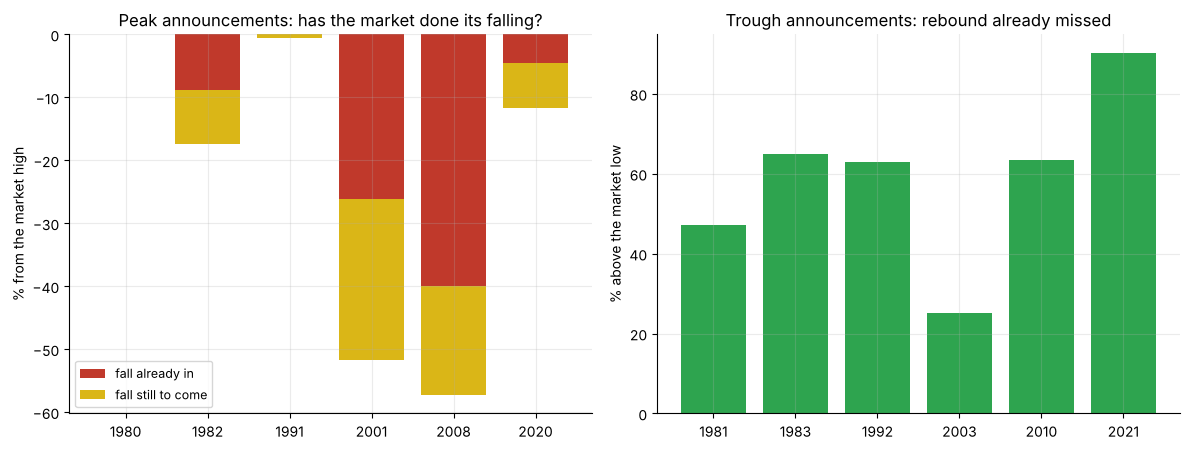

,kind,date,lag_months,already,still_to_come,fwd_12m,tape
0,peak,1980-06-03,5,0.000,0.000,0.249,FF total return
1,trough,1981-07-08,12,0.471,NaN,-0.148,FF total return
2,peak,1982-01-06,6,-0.088,-0.086,0.296,FF total return
3,trough,1983-07-08,8,0.649,NaN,-0.072,FF total return
4,peak,1991-04-25,9,0.000,-0.006,0.153,FF total return
5,trough,1992-12-22,21,0.630,NaN,0.111,FF total return
6,peak,2001-11-26,8,-0.261,-0.257,-0.149,FF total return
7,trough,2003-07-17,20,0.252,NaN,0.134,FF total return
8,peak,2008-12-01,12,-0.400,-0.174,0.284,FF total return
9,trough,2010-09-20,15,0.635,NaN,0.003,FF total return


In [5]:
at_m = st.announcement_table(tr, anns)
at_d = st.announcement_table(d, anns, bars_per_month=21)
best = st.best_available(at_m, at_d)
pk, tg = best[best.kind == "peak"], best[best.kind == "trough"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].bar(pk.date.dt.year.astype(str), pk.already * 100, color=RED, label="fall already in")
axes[0].bar(pk.date.dt.year.astype(str), pk.still_to_come * 100, bottom=pk.already * 100,
            color=AMBER, label="fall still to come")
axes[0].set_title("Peak announcements: has the market done its falling?")
axes[0].set_ylabel("% from the market high"); axes[0].legend(fontsize=9)
axes[1].bar(tg.date.dt.year.astype(str), tg.already * 100, color=GREEN)
axes[1].set_title("Trough announcements: rebound already missed")
axes[1].set_ylabel("% above the market low")
plt.tight_layout(); plt.show()
best[["kind", "date", "lag_months", "already", "still_to_come", "fwd_12m", "tape"]]

The two halves of the claim come apart here. At **trough** announcements the claim is right —
the market was already a median **+63%** off its low. At **peak** announcements it is only
half right: in 2008 the market was down 40% when the news came, but in 1980 and 1991 it had
barely fallen, and in 2001 half the bear market was still ahead.

### 4.3 Is the announcement a buy signal?

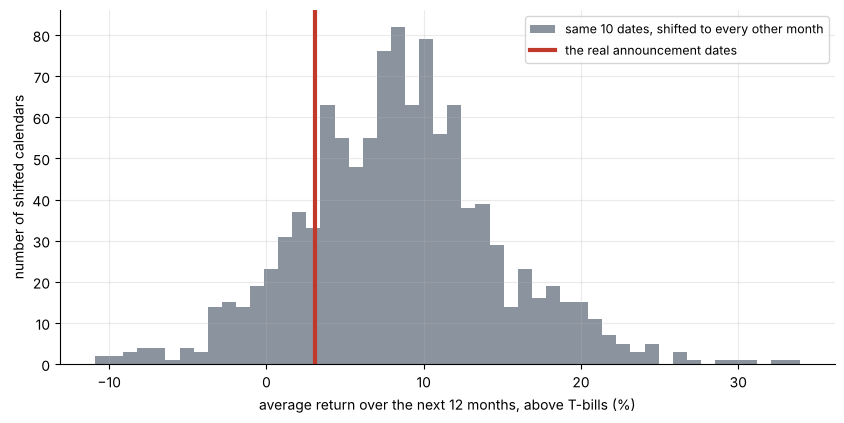

after the announcements: +3.1%   after random dates: +8.5%   share of random calendars doing at least as well: 82%


In [6]:
pos = st.event_positions(xs.index, anns)
r = st.rotation_test(xs, pos, 12)
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.hist(r["perm"] * 100, bins=50, color=GREY, label="same 10 dates, shifted to every other month")
ax.axvline(r["observed"] * 100, color=RED, lw=3, label="the real announcement dates")
ax.set_xlabel("average return over the next 12 months, above T-bills (%)")
ax.set_ylabel("number of shifted calendars"); ax.legend(fontsize=9)
plt.show()
print(f"after the announcements: {r['observed']:+.1%}   after random dates: "
      f"{r['null_mean']:+.1%}   share of random calendars doing at least as well: "
      f"{r['p_one_sided']:.0%}")

The red line sits in the *middle-left* of the grey pile. Buying on the official dates did
worse than buying on most shifted versions of the same calendar.

### 4.4 Could twelve dates ever have told us? (synthetic)

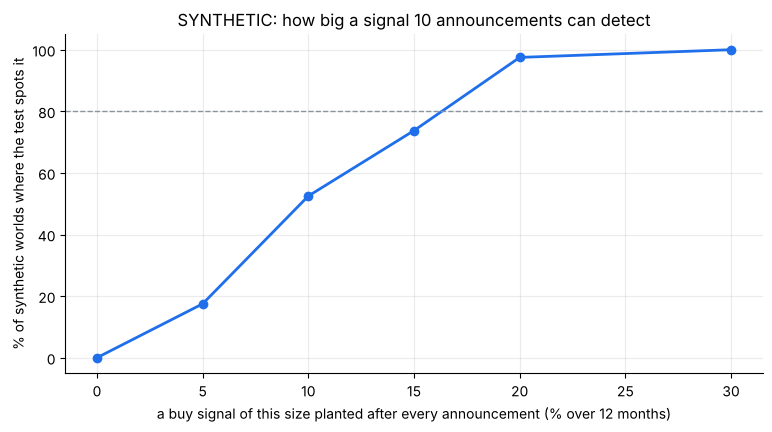

In [7]:
pc = st.power_curve(effects=(0.0, 0.05, 0.10, 0.15, 0.20, 0.30), n_sims=80,
                    vol=float(m.mkt.std() * np.sqrt(12)))
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(pc.index * 100, pc.reject_rate * 100, "o-", color=BLUE, lw=2)
ax.axhline(80, color=GREY, ls="--", lw=1)
ax.set_xlabel("a buy signal of this size planted after every announcement (% over 12 months)")
ax.set_ylabel("% of synthetic worlds where the test spots it")
ax.set_title("SYNTHETIC: how big a signal 10 announcements can detect")
plt.show()

With only ten announcements on the total-return tape, the test spots a planted buy signal most
of the time only once it is worth about **17%** extra over a year. So "no signal" here means
"no *big* signal". It cannot rule out a small one, and neither can anyone else with this
history.

## Beat 5 · The verdict

**Signal: Mixed — Real on the lead · None on the buy signal.** The market bottomed before the
official trough in 14 of 15 cycles, and that beats what the method produces on arbitrary
dates (p = 0.032). The announcement itself carries no detectable timing information
(p = 0.82).

**Tradability: Mirage.** See below.

## Beat 6 · Could you trade it?

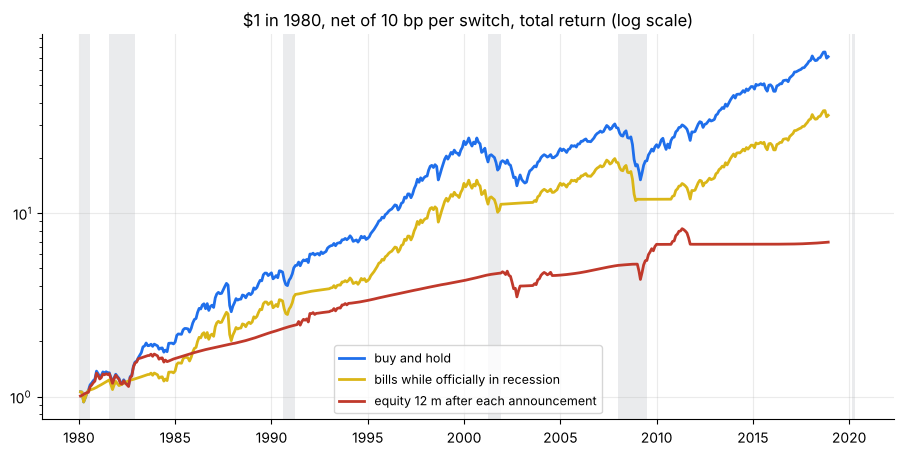

In [8]:
mm = m[m.index >= "1980-01-01"]
sig = {"bills while officially in recession": st.signal_avoid(mm.index, anns),
       "equity 12 m after each announcement": st.signal_buy_after(mm.index, anns, 12)}
fig, ax = plt.subplots(figsize=(11, 5))
bh = st.timing_backtest(mm.mkt, mm.rf, pd.Series(1.0, index=mm.index))
ax.semilogy((1 + bh["net_series"]).cumprod(), color=BLUE, lw=2, label="buy and hold")
for (name, s_), col in zip(sig.items(), (AMBER, RED)):
    b = st.timing_backtest(mm.mkt, mm.rf, s_, cost_bps=10)
    ax.semilogy((1 + b["net_series"]).cumprod(), color=col, lw=2, label=name)
shade_recessions(ax, lo=mm.index[0])
ax.set_title("$1 in 1980, net of 10 bp per switch, total return (log scale)")
ax.legend(fontsize=9); plt.show()

Neither the believer ("buy on the news") nor the sceptic ("it's official — get out until it's
over") beats simply holding. The buyer sits in cash most of the time and misses the market's
long climb; the seller gets out after the damage and comes back after the rebound. Costs barely
matter — it is the timing that loses.

## Beat 7 · Going further 🚪

- **The trough-announcement curiosity.** The year after a "recovery is official" release was
  *below* random dates (one-tailed p ≈ 0.07, five events). Is it a real "easy money
  is gone" effect or noise? Other countries' official cycle dating (e.g. the CEPR committee for
  the euro area) would add independent events.
- **Real-time recession probabilities** (yield curve, Sahm rule) move *before* the committee —
  see the neighbouring studies 268-sahm-rule and 626-unemployment-trend-timing.
- **Fork it:** change the windows in `nberclock.strategy.lead_lag` and watch the lead's
  p-value; it survives 8 of 9 of the window choices we tried.